<a href="https://colab.research.google.com/github/Harisudharshan-2005/Hari_summer_internship/blob/main/miniday3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
API_KEY = 'c1a17065da8d515c78f9d4a88be534d6'

In [12]:
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

In [13]:
CITIES = ['Mumbai ','Delhi','Bangalore','Chennai','Hyderabad ','Kolkata','Pune','Jaipur']

In [14]:
print(f'API configured for {len(CITIES)}cities')
print(f"Cities: {CITIES}")

API configured for 8cities
Cities: ['Mumbai ', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad ', 'Kolkata', 'Pune', 'Jaipur']


In [9]:
def fetch_weather(city,api_key):
    params = {
        'q':city,
        'appid':api_key,
        'units':'metric'
    }
    response = requests.get(BASE_URL,params=params,timeout=10)
    data = response.json()
    return {
        'city': city,
        'temperature':round(data['main']['temp'],1),
        'feels_like':round(data['main']['feels_like'],1),
        'humidity':data['main']['humidity'],
        'description':data['weather'][0]['description'],
        'icon':data['weather'][0]['icon'],
        'humidity':round(data['main'])
    }


In [17]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [27]:
Chennai_city = fetch_weather(CITIES[3],API_KEY)
print("Fetching the API KEY !!!!!!")
print("")
if Chennai_city:
  print(Chennai_city)
else:
  print('Error fetching weather data')


Fetching the API KEY !!!!!!

{'city': 'Chennai', 'temperature': 36.0, 'description': 'few clouds', 'humidity': 54, 'wind_speed': 5.14, 'pressure': 1005, 'condition': 'Few Clouds', 'visibility': 6}


In [31]:
import pandas as pd

print("Fetching weather data for all cities...")
print("")

all_cities_weather_data = []
for city_name in CITIES:
  city_weather = fetch_weather(city_name, API_KEY)
  if city_weather:
    all_cities_weather_data.append(city_weather)
  else:
    print(f'Could not fetch weather data for {city_name}')

print("")
print("-"*80)

if all_cities_weather_data:
  pdf = pd.DataFrame(all_cities_weather_data)
  print(pdf)
else:
  print("No weather data was successfully fetched for any city.")

Fetching weather data for all cities...


--------------------------------------------------------------------------------
         city  temperature       description  humidity  wind_speed  pressure  \
0     Mumbai          34.0              haze        59        6.17      1009   
1       Delhi         44.0         clear sky        10        5.14       999   
2   Bangalore         29.8  scattered clouds        54        7.15      1009   
3     Chennai         35.8        few clouds        53        5.14      1005   
4  Hyderabad          31.2     broken clouds        51        8.75      1008   
5     Kolkata         32.0              haze        62        4.12      1001   
6        Pune         36.9   overcast clouds        27        3.76      1008   
7      Jaipur         42.6              haze        15        5.14      1001   

          condition  visibility  
0              Haze           7  
1         Clear Sky           7  
2  Scattered Clouds           8  
3        Few Clouds 

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
if len(all_cities_weather_data)==0:
  print("Using fallback data for plotting")
else:
  data = all_cities_weather_data
  pdf = pd.DataFrame(all_cities_weather_data)
  display(pdf)
  print("-"*80)
  print(pdf.to_string(index=False))
  print(f"\nShape : ",pdf.shape)
  print(f"\nMissing Values : ",pdf.isnull().sum())
  print(f'\nData Types : ')
  print(pdf.dtypes)

,city,temperature,description,humidity,wind_speed,pressure,condition,visibility
0,Mumbai,34.0,haze,59,6.17,1009,Haze,7
1,Delhi,44.0,clear sky,10,5.14,999,Clear Sky,7
2,Bangalore,29.8,scattered clouds,54,7.15,1009,Scattered Clouds,8
3,Chennai,35.8,few clouds,53,5.14,1005,Few Clouds,6
4,Hyderabad,31.2,broken clouds,51,8.75,1008,Broken Clouds,6
5,Kolkata,32.0,haze,62,4.12,1001,Haze,5
6,Pune,36.9,overcast clouds,27,3.76,1008,Overcast Clouds,10
7,Jaipur,42.6,haze,15,5.14,1001,Haze,5


--------------------------------------------------------------------------------
      city  temperature      description  humidity  wind_speed  pressure        condition  visibility
   Mumbai          34.0             haze        59        6.17      1009             Haze           7
     Delhi         44.0        clear sky        10        5.14       999        Clear Sky           7
 Bangalore         29.8 scattered clouds        54        7.15      1009 Scattered Clouds           8
   Chennai         35.8       few clouds        53        5.14      1005       Few Clouds           6
Hyderabad          31.2    broken clouds        51        8.75      1008    Broken Clouds           6
   Kolkata         32.0             haze        62        4.12      1001             Haze           5
      Pune         36.9  overcast clouds        27        3.76      1008  Overcast Clouds          10
    Jaipur         42.6             haze        15        5.14      1001             Haze           5



In [41]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

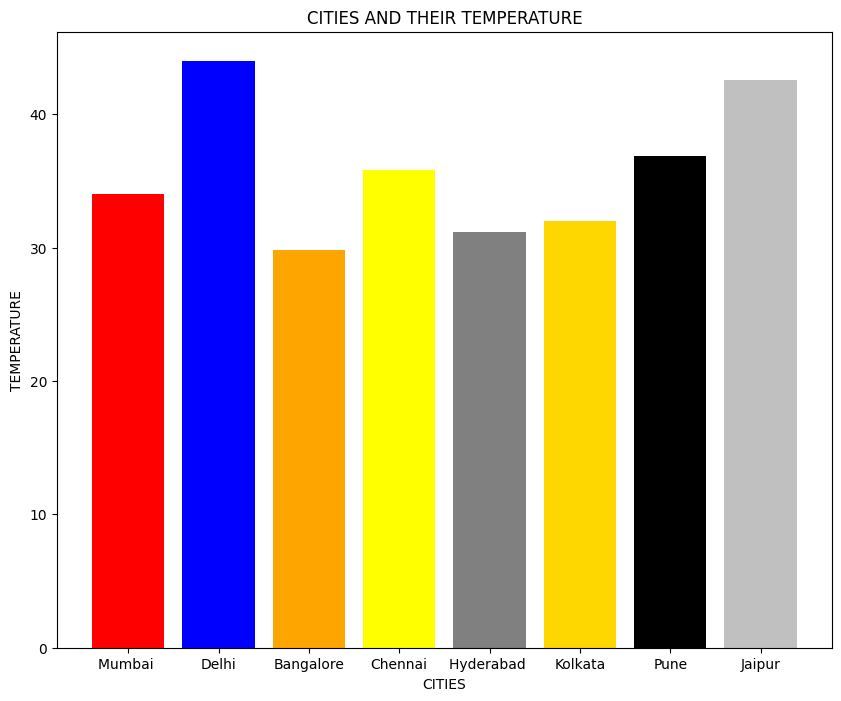

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("TEMPERATURE")
plt.title("CITIES AND THEIR TEMPERATURE")
plt.bar(pdf['city'],pdf['temperature'],color = ['red','blue','orange','yellow','grey','gold','black','silver'])
plt.show()

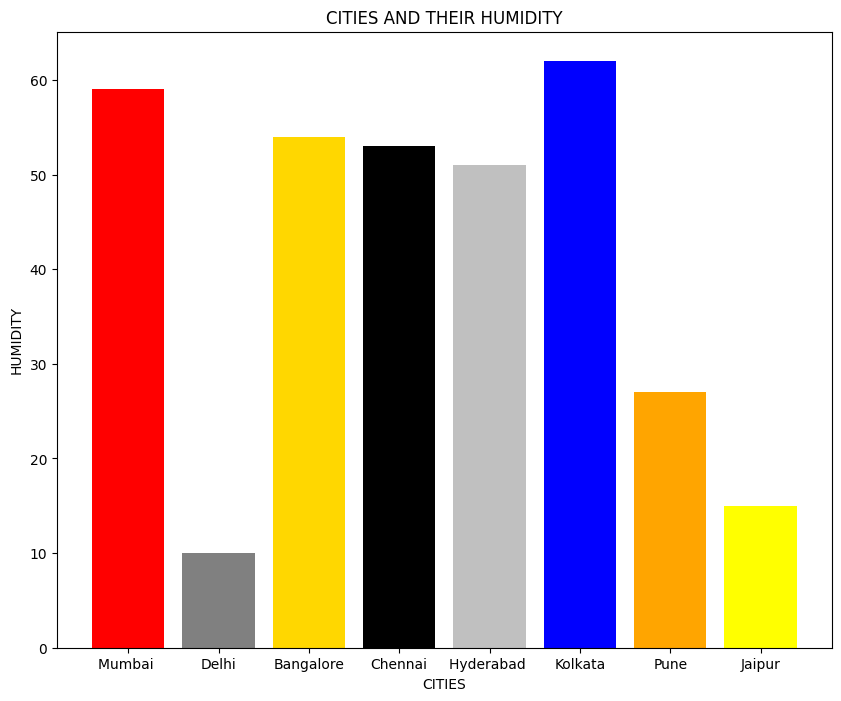

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("HUMIDITY")
plt.title("CITIES AND THEIR HUMIDITY")
plt.bar(pdf['city'],pdf['humidity'],color = ['red','grey','gold','black','silver','blue','orange','yellow'])
plt.show()

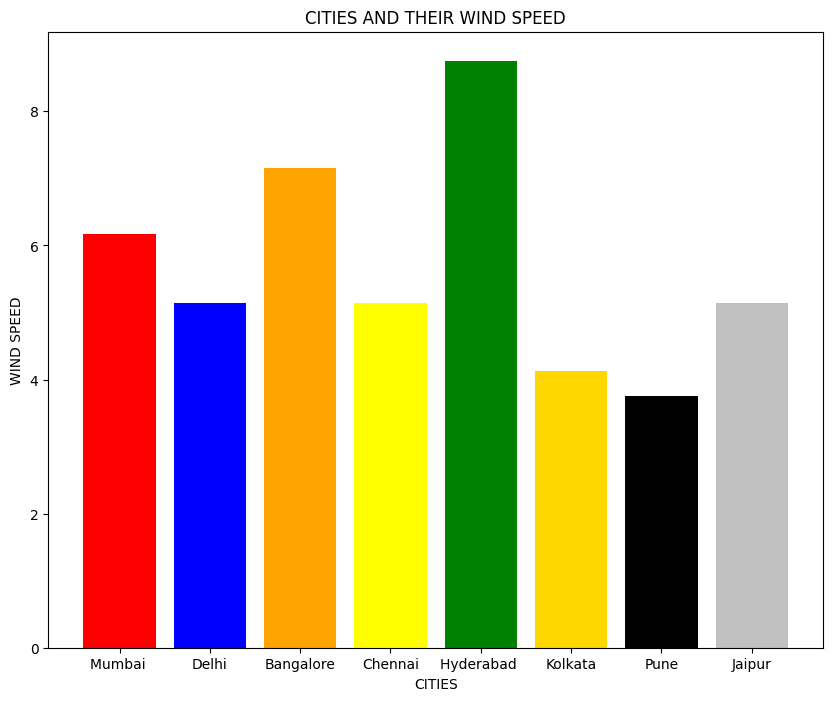

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("WIND SPEED")
plt.title("CITIES AND THEIR WIND SPEED")
plt.bar(pdf['city'],pdf['wind_speed'],color = ['red','blue','orange','yellow','green','gold','black','silver'])
plt.show()